In [69]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [71]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv(r"C:\Users\user\Downloads\penguins.csv")
print(data.head())
print(data.shape)
print(data.isnull().sum())
print(data.dtypes)



   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g     sex
0              39.1             18.7              181.0       3750.0    MALE
1              39.5             17.4              186.0       3800.0  FEMALE
2              40.3             18.0              195.0       3250.0  FEMALE
3               NaN              NaN                NaN          NaN     NaN
4              36.7             19.3              193.0       3450.0  FEMALE
(344, 5)
culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


In [73]:
print(data['sex'].unique())


['MALE' 'FEMALE' nan '.']


In [75]:
data['sex'] = data['sex'].replace('.', np.nan).str.upper()
data=data.dropna()
data['sex_encoded'] = data['sex'].map({'MALE': 0, 'FEMALE': 1})
data= data.drop(columns=['sex'])


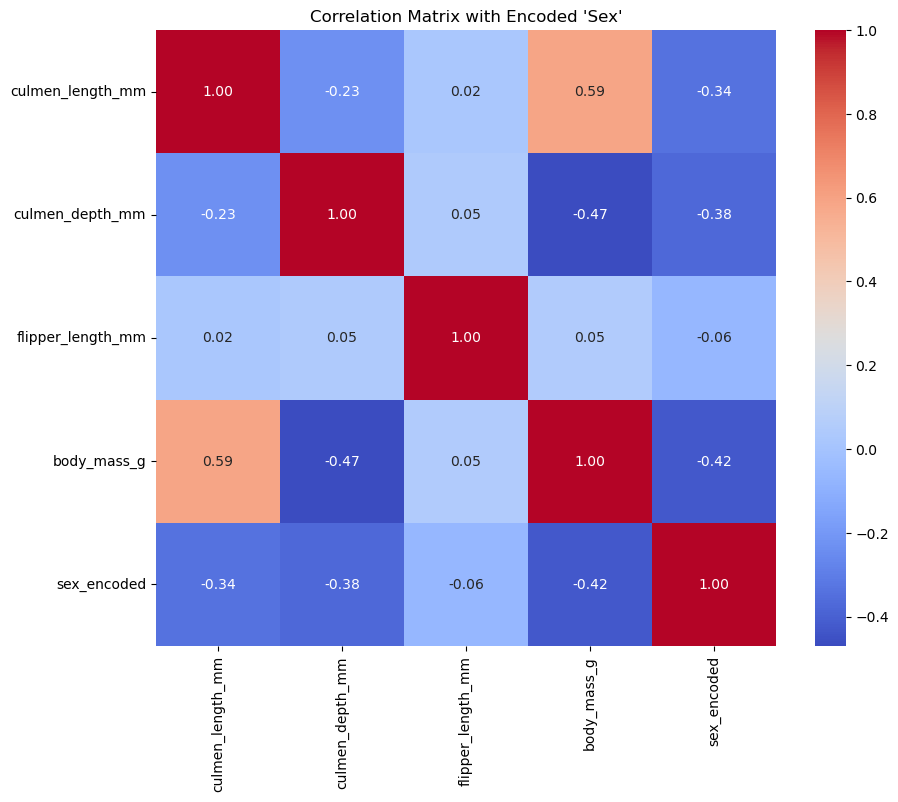

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = data.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix with Encoded 'Sex'")
plt.show()


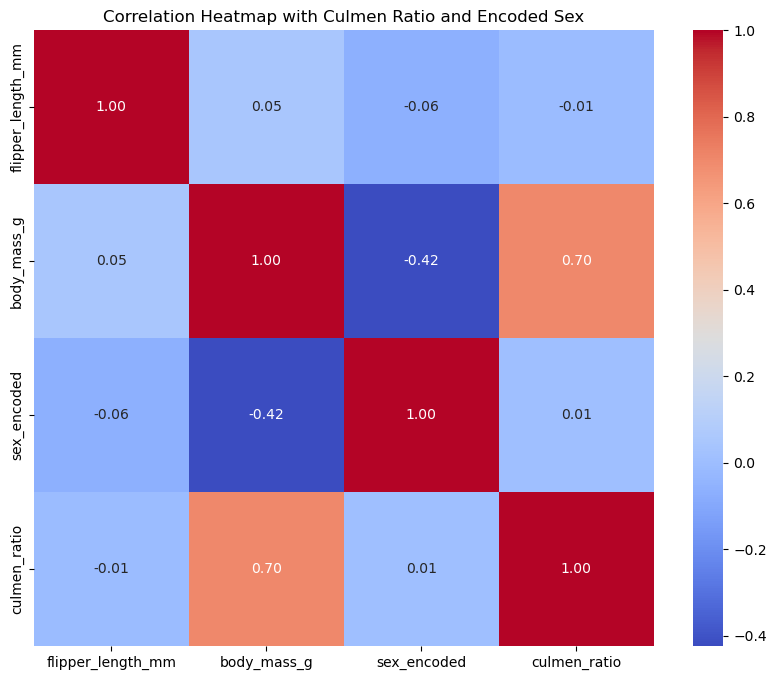

In [105]:
from sklearn.preprocessing import LabelEncoder

df = data.dropna(subset=['culmen_length_mm', 'culmen_depth_mm'])

df['culmen_ratio'] = df['culmen_length_mm'] / df['culmen_depth_mm']

df = df.drop(columns=['culmen_length_mm', 'culmen_depth_mm'])

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap with Culmen Ratio and Encoded Sex")
plt.show()


In [128]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = ['culmen_ratio', 'flipper_length_mm', 'body_mass_g']
X = df[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)  
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)


[0.86429211 0.09996906]


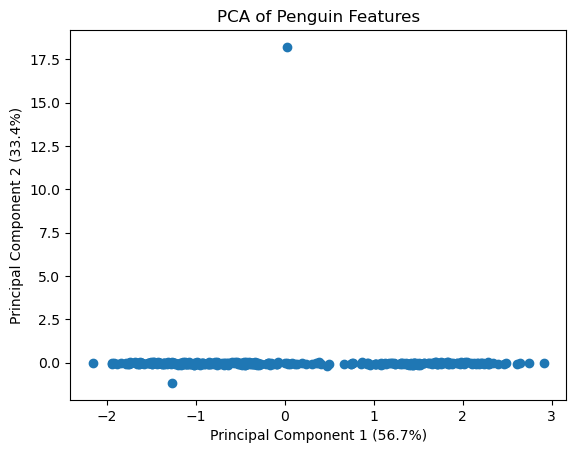

In [109]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel('Principal Component 1 (56.7%)')
plt.ylabel('Principal Component 2 (33.4%)')
plt.title('PCA of Penguin Features')
plt.show()


In [111]:
import numpy as np

outlier_index = np.argmax(np.abs(X_pca[:, 1]))
print("Outlier index:", outlier_index)
print("Original data for outlier:\n", df.iloc[outlier_index])


Outlier index: 7
Original data for outlier:
 flipper_length_mm    5000.000000
body_mass_g          4250.000000
sex_encoded             0.000000
culmen_ratio            2.079208
Name: 9, dtype: float64


In [113]:
df = df.drop(9) 


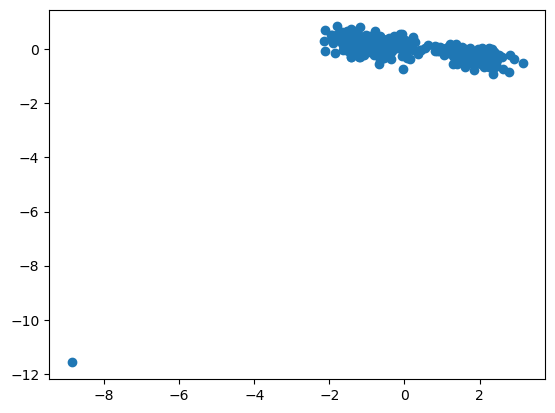

In [115]:
features = ['culmen_ratio', 'flipper_length_mm', 'body_mass_g']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.show()


In [117]:
import numpy as np
outlier_idx = np.argmin(X_pca[:, 1]) 
print("Outlier index:", outlier_idx)
print(df.iloc[outlier_idx])


Outlier index: 9
flipper_length_mm    -132.00000
body_mass_g          4400.00000
sex_encoded             0.00000
culmen_ratio            1.63981
Name: 14, dtype: float64


In [119]:
df = df.drop(14) 


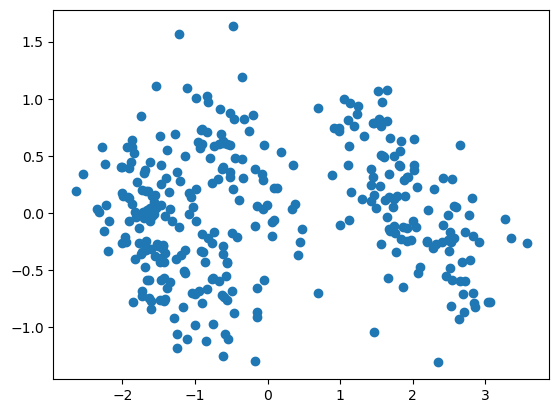

In [121]:
features = ['culmen_ratio', 'flipper_length_mm', 'body_mass_g']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.show()


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

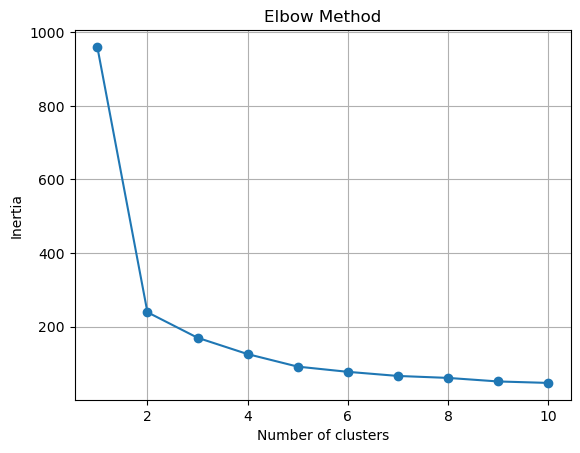

In [123]:
clusters = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)  
    clusters.append(kmeans.inertia_)  

# Now plot correctly
plt.plot(range(1, 11), clusters, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [130]:
from sklearn.metrics import silhouette_score

optimal_k= 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_pca)
labels = kmeans.labels_
score = silhouette_score(X_pca, labels)
print("Silhouette Score:", score)


Silhouette Score: 0.6424855004395854


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
